# 5. Boosted Trees

Class of ML algorothms that produce a prediction model from an ensemble of weak prediction models, like decision trees. Model is constructed in a stage-wise fashion and generalized using an arbitrary loss function. Boosting methods are useful in the absence of good domain knowledge, as a good first choice for creating and interpretable OOTB solution.

Some features include:
* parallelization
* antively handle missing values and outliers
* require minimal data preprocessing

## 5a. Introduction

* Approach a binary classification problem with `BoostedTreesClassifier`
* Hotel dataset: predicting which customers are likely to cancel their booking

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd

from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
sns_colours = sns.color_palette('colorblind')

from numpy.random import uniform, seed
from scipy.interpolate import griddata
from sklearn.metrics import roc_curve

In [27]:
# *Note: categorical variables can be recorded as integers in a gradient boosting model
# 	Good because of minimal preprocessing
# Function here demonstrate the interpretability of the model, analyze individual indicator values

def one_hot_cat_column(feature_name, vocab):
    '''
    perform one-hot encoding in a TF-friendly format on categorical variables.
    used to analyze individual indicator variables
    '''
    return tf.feature_column.indicator_column(
		tf.feature_column.categorical_column_with_vocabulary_list(feature_name, vocab)
	)


In [28]:
# Instantiating hotel dataset
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [29]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [30]:
# Splitting data
xvalid = df[df['reservation_status_date'] >= '2017-08-01']
xtrain = df[df['reservation_status_date'] < '2017-08-01']

# separate features from targets
ytrain, yvalid = xtrain['is_canceled'], xvalid['is_canceled']
xtrain.drop('is_canceled', axis=1, inplace=True)
xvalid.drop('is_canceled', axis=1, inplace=True)

# separate numerical and categorical columns +
# skip columns that might introduce leakage (e.g arrival_date_year)
# 	information that might improve model performance, but fail when predicting unseen data
#	leakage can be detected as one very important feature dominating over others
xtrain.drop(['arrival_date_year','assigned_room_type', 'booking_changes', 'reservation_status',
             'country', 'days_in_waiting_list'], axis =1, inplace = True)

num_features = ["lead_time","arrival_date_week_number","arrival_date_day_of_month",
                "stays_in_weekend_nights","stays_in_week_nights","adults","children",
                "babies","is_repeated_guest", "previous_cancellations",
                "previous_bookings_not_canceled","agent","company",
                "required_car_parking_spaces", "total_of_special_requests", "adr"]

cat_features = ["hotel","arrival_date_month","meal","market_segment",
                "distribution_channel","reserved_room_type","deposit_type","customer_type"]

feature_columns = []
for feature_name in cat_features:
    # Need to one-hot encode the categorical features
    vocabulary = xtrain[feature_name].unique()
    feature_columns.append(one_hot_cat_column(feature_name, vocabulary))

for feature_name in num_features:
    feature_columns.append(tf.feature_column.numeric_column(feature_name, dtype=tf.float32))
feature_columns

c:\Users\Martin Ho\Languages\python38\lib\site-packages\pandas\core\frame.py:4157: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


[IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='hotel', vocabulary_list=('Resort Hotel', 'City Hotel'), dtype=tf.string, default_value=-1, num_oov_buckets=0)),
 IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='arrival_date_month', vocabulary_list=('July', 'August', 'September', 'October', 'November', 'December', 'January', 'February', 'March', 'April', 'May', 'June'), dtype=tf.string, default_value=-1, num_oov_buckets=0)),
 IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='meal', vocabulary_list=('BB', 'FB', 'HB', 'SC', 'Undefined'), dtype=tf.string, default_value=-1, num_oov_buckets=0)),
 IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='market_segment', vocabulary_list=('Direct', 'Corporate', 'Online TA', 'Offline TA/TO', 'Complementary', 'Groups', 'Undefined', 'Aviation'), dtype=tf.string, default_value=-1, num_oov_buckets=0)),
 IndicatorColumn(categorical_column=VocabularyListCategoricalColu

Removing variables can help prevent leakage. Methods include: (1) Expert judgement prior to the modelling procedure (2) running small models to examine the global importance of features. If the model is highly dependent on a feature, a dominating feature, it is a potential source of leakage.

In [33]:
# Creating the input functions to pass data into the model
NUM_EXAMPLES = len(ytrain)
def make_input_fn(X, y, n_epochs=None, shuffle=True):
    
    def input_fn():
        dataset = tf.data.Dataset.from_tensor_slices((dict(X), y))
        if shuffle:
            dataset = dataset.shuffle(NUM_EXAMPLES)
		# for training, cycle through dataset as many times as needed (default: None)
        dataset = dataset.repeat(n_epochs)
		# in memory trainind doesn't use batching
        dataset = dataset.batch(NUM_EXAMPLES)
        return dataset
    return input_fn

# training and evaluation input functions
train_input_fn = make_input_fn(xtrain, ytrain)
eval_input_fn = make_input_fn(xvalid, yvalid, shuffle=False, n_epochs=1)	

In [34]:
# Build the BoostedTrees model
params = {
	'n_trees': 125,
	'max_depth': 5, # key param to determine how deep the tree gets
	'n_batches_per_layer': 1,
	'center_bias': True
}
est = tf.estimator.BoostedTreesClassifier(feature_columns, **params)

# Train model
est.train(train_input_fn, max_steps=100) 

INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\MARTIN~1\\AppData\\Local\\Temp\\tmpsvkw052d', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}
INFO:tensorflow:Calling model_fn.
INFO:tens

In [35]:
# Evaluation
results = est.evaluate(eval_input_fn) # evaluate method will cover a wide range of possible metrics
pd.Series(results).to_frame()

INFO:tensorflow:Calling model_fn.
Instructions for updating:
The value of AUC returned by this may race with the update so this is deprecated. Please use tf.keras.metrics.AUC instead.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Starting evaluation at 2022-07-25T23:27:56Z
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from C:\Users\MARTIN~1\AppData\Local\Temp\tmpsvkw052d\model.ckpt-100
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.
INFO:tensorflow:Inference Time : 0.82261s
INFO:tensorflow:Finished evaluation at 2022-07-25-23:27:56
INFO:tensorflow:Saving dict for global step 100: accuracy = 0.7391076, accuracy_baseline = 0.9160105, auc = 0.64406025, auc_precision_recall = 0.1987788, average_loss = 0.52716064, global_step = 100, label/mean = 0.0839895, loss = 0.52716064, precision = 0.12885463, prediction/mean = 0.35162488, recall = 0.365625
Type is unsupported, or the types of the items don't match field type in Co

,0
accuracy,0.739108
accuracy_baseline,0.916010
auc,0.644060
auc_precision_recall,0.198779
average_loss,0.527161
label/mean,0.083990
loss,0.527161
precision,0.128855
prediction/mean,0.351625
recall,0.365625


In [37]:
# Prediction
pred_dicts = list(est.predict(eval_input_fn))
probs = pd.Series([pred['probabilities'][1] for pred in pred_dicts])
probs

INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from C:\Users\MARTIN~1\AppData\Local\Temp\tmpsvkw052d\model.ckpt-100
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.


0       0.630442
1       0.601515
2       0.679339
3       0.679339
4       0.679339
          ...   
3805    0.207812
3806    0.486409
3807    0.331495
3808    0.693753
3809    0.435712
Length: 3810, dtype: float64

Evaluation can be done at different levels of geenrality - details between the global and local are follows.

__Receiver Opertaing Characteristic (ROC)__

Graph that shows the performance of a classification model at all possible classification thresholds. Plots the false positive rate to true positive rate: a random classifier would be a diagonal line from (0,0) to (1,1). So the closer the curve is to the upper-left corner, the better the classifier

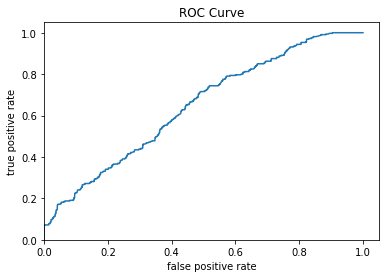

In [38]:
fpr, tpr, _ = roc_curve(yvalid, probs)
plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.xlim(0,)
plt.ylim(0,)
plt.show()

# 5b. Model Interpretation

Understanding the importance of each feature relative to the model and predictions.

Code block extracts the feature contributions to a prediction of a data point. Plot feature importances using different colours, depending on whether the contribution is positive or negative.

### Local Interpretability

Refers to an understanding of a model's predictions at an individual example level. For example:

1. Why did the model predict this data point like this?
2. Which feature made the most impact in the model?
3. Why was this feature chosen for this prediction?

Useful if model predictions need to be explained to audiences with technical cognitive diversity. These are called __directional feature contributions (DFCs)__. Each row contain summary statistics of the directional contributions of a feature across all observations in the validation set.

In [39]:
pred_dicts = list(est.experimental_predict_with_explanations(eval_input_fn))

# Create DFC Pandas Dataframe
labels = yvalid.values
probs = pd.Series([pred['probabilities'][1] for pred in pred_dicts])
df_dfc = pd.DataFrame([pred['dfc'] for pred in pred_dicts])
df_dfc.describe().T

INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\MARTIN~1\\AppData\\Local\\Temp\\tmpsvkw052d', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}
INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:ten

,count,mean,std,min,25%,50%,75%,max
arrival_date_day_of_month,3810.0,0.015021,0.025960,-0.009088,0.000000,0.002730,0.016752,0.111898
arrival_date_week_number,3810.0,0.016586,0.021825,-0.030400,0.003800,0.010386,0.017452,0.129319
arrival_date_month,3810.0,0.021037,0.018687,-0.028264,0.008968,0.016866,0.031217,0.097243
adr,3810.0,0.017408,0.024890,-0.042030,0.000579,0.009708,0.030678,0.132454
lead_time,3810.0,-0.004297,0.059970,-0.217446,-0.033285,0.006692,0.030761,0.128644
agent,3810.0,0.001850,0.019047,-0.102174,-0.006765,0.000036,0.012159,0.097824
previous_cancellations,3810.0,-0.022823,0.020035,-0.069968,-0.032872,-0.027794,-0.007104,0.282555
deposit_type,3810.0,-0.022853,0.013961,-0.083660,-0.025416,-0.022780,-0.021911,0.153590
market_segment,3810.0,-0.008381,0.041706,-0.188447,-0.046222,-0.003042,0.020951,0.094277
required_car_parking_spaces,3810.0,-0.016666,0.037204,-0.157734,-0.016540,-0.007961,-0.003839,0.034643


In [40]:
def _get_colour(value):
    '''Make positive DFCs plot green, negative DFCs plot red'''
    green, red = sns.color_palette()[2:4]
    if value >= 0:
        return green
    return red 

def _add_feature_values(feature_values, ax):
    '''Display feature's values on left of plot'''
    x_coord = ax.get_xlim()[0]
    OFFSET = 0.15
    for y_coord, (feat_name, feat_val) in enumerate(feature_values.items()):
       t = plt.text(x_coord, y_coord - OFFSET, '{}'.format(feat_val), size=12)
       t.set_bbox(dict(facecolor='white', alpha=0.5))
    from matplotlib.font_manager import FontProperties
    font = FontProperties()
    font.set_weight('bold')
    t = plt.text(x_coord, y_coord + 1 - OFFSET, 'feature\nvalue', fontproperties=font, size=12)

def plot_example(example):
    TOP_N = 8 # view top 8 features
    sorted_ix = example.abs().sort_values()[-TOP_N:].index
    example = example[sorted_ix]
    colours = example.map(_get_colour).tolist()
    ax = example.to_frame().plot(
		kind='barh',
		color=[colours],
		legend=None,
		alpha=0.75,
		figsize=(10, 6)
	)
    ax.grid(False, axis='y')
    ax.set_yticklabels(ax.get_yticklabels(), size=14)
    # add feature values
    _add_feature_values(xvalid.iloc[ID][sorted_ix], ax)
    return ax

In [ ]:
# Plot the detailed graph
ID = 10
TOP_N = 8 # View top 8 features

example = df_dfc.iloc[ID] # Choose ith example from evaluation dataset
sorted_ix = example.abs().sort_values()[-TOP_N:].index
ax = plot_example(example)
ax.set_title('Feature contributions for example {}\n pred: {:1.2f}; label: {}'.format(ID, probs[ID], labels[ID]))
ax.set_xlabel('Contribution to predicted probability', size=14)

plt.show()

### Global Interpretability 

Understanding of the model as a whole: visualize gain-based feature importance and permutation feature importance and show aggregated DFCs.

* Gain-based feature importance: measure the loss change when splitting on a particular feature
* Permutation feature importance: model performance changed by shuffling a feature around when splitting 

Permuitation is usually preferred over gain-based feature importance, but both methods can be unreliable when:

1. predictors can be different based on their scale of measurement or number of categories
2. the features are correlated 

In [3]:
def permutation_importances(est, X_eval, y_eval, metric, features):
    """Column by column, shuffle values and observe effect on eval set.

    source: http://explained.ai/rf-importance/index.html
    A similar approach can be done during training. See "Drop-column importance"
    in the above article."""
    baseline = metric(est, X_eval, y_eval)
    imp = []
    for col in features:
        save = X_eval[col].copy()
        X_eval[col] = np.random.permutation(X_eval[col])
        m = metric(est, X_eval, y_eval)
        X_eval[col] = save
        imp.append(baseline - m)
    return np.array(imp)

def accuracy_metric(est, X, y):
    """TensorFlow estimator accuracy"""
    eval_input_fn = make_input_fn(
		X,
		y=y,
		shuffle=False,
		n_epochs=1
	)
    return est.evaluate(input_fn=eval_input_fn)['accuracy']

In [ ]:
# Display the most relevant columns - Permutation Importance
features = cat_features + num_features
importances = permutation_importances(est, xvalid, yvalid, accuracy_metric,
                                      features)
df_imp = pd.Series(importances, index=features)

sorted_ix = df_imp.abs().sort_values().index
ax = df_imp[sorted_ix][-5:].plot(kind='barh', color=sns_colors[2], figsize=(10, 6))
ax.grid(False, axis='y')
ax.set_title('Permutation feature importance')

plt.show()

In [ ]:
# Display the most relevant columns - Gain-feature Importance
importances = est.experimental_feature_importances(normalize=True)
df_imp = pd.Series(importances)

# Visualize importances.
N = 8
ax = (df_imp.iloc[0:N][::-1]
    .plot(kind='barh',
          color=sns_colors[0],
          title='Gain feature importances',
          figsize=(10, 6)))
ax.grid(False, axis='y')

In [ ]:
# Absolue values of DFCs can be averages to understand global level impact
dfc_mean = df_dfc.abs().mean()
N = 8
sorted_ix = dfc_mean.abs().sort_values()[-N:].index  # Average and sort by absolute.
ax = dfc_mean[sorted_ix].plot(kind='barh',
                       color=sns_colors[1],
                       title='Mean |directional feature contributions|',
                       figsize=(10, 6))
ax.grid(False, axis='y')

# Summary

`GradientBoostingClassifier`: Flexible model architecture application to a wide range of tabular data problems.

TF Boosted Trees Pipeline:

* Prepare the data for use with the model
* Configure the `GradientBoostingClassifier` with `tf.estimator`
* Evaluate the feature importance and model interpretability, both on a global and local level